## Source — Pourquoi le dataset mexicain ?

Le dataset du gouvernement mexicain (SISVER - Sistema de Vigilancia Epidemiológica de Enfermedades Respiratorias) est à ce jour l'un des seuls jeux de
données cliniques COVID-19 **massifs, individuels et entièrement open source**
disponibles publiquement. La grande majorité des pays, notamment la France, ont
collecté des données similaires via leurs systèmes nationaux (SI-DEP en France)
mais ne les ont jamais rendues publiques au niveau individuel patient par patient,
en raison des contraintes imposées par les législations sur la protection des
données personnelles (RGPD en Europe).

Le dataset mexicain se distingue par plusieurs aspects uniques :

- **Volume** : plus de 2,3 millions de dossiers patients anonymisés
- **Richesse** : 38 variables cliniques par patient (comorbidités, gravité, démographie)
- **Période** : couvre le début de la pandémie dès janvier 2020
- **Accessibilité** : publié sous licence libre par la Secretaría de Salud

C'est donc le dataset le plus adapté à notre projet, offrant une base statistique
suffisamment large pour que les algorithmes non supervisés (K-means, DBSCAN)
puissent identifier des groupes de patients aux profils cliniques cohérents et
représentatifs.

1. Plot statistique        → Explorer et comprendre les données brutes
2. Normalisation           → Mettre toutes les variables à la même échelle
3. Centrage                → Moyenne à 0 (nécessaire avant PCA)
4. Covariance / Variance   → Comprendre les relations entre variables
5. PCA                     → Réduire la dimension + trouver le meilleur nombre de composantes
6. K-means ou DBSCAN       → Clustering sur les composantes PCA
7. Explication des données → Identifier les variables les plus importantes par cluster


```
┌─────────────────────────────────────────┐
│              SPARK / MLlib              │
│                                         │
│  Lecture CSV  →  Nettoyage  →           │
│  Normalisation  →  PCA  →  K-means      │
└────────────────────┬────────────────────┘
                     │
          Résultats exportés
                     │
┌────────────────────▼────────────────────┐
│          SCIKIT-LEARN / SHAP            │
│                                         │
│  DBSCAN  →  Elbow  →  Silhouette  →    │
│  SHAP  →  Interprétation clusters       │
└─────────────────────────────────────────┘
```

### 1. Plot statistique — Explorer et comprendre les données brutes

## Lecture des données COVID-19 mexicain

La première chose à faire est de charger le dataset dans Python et d'en explorer la structure. On utilise [pandas](http://pandas.pydata.org) (importé sous `pd`) pour la lecture CSV et la manipulation du `DataFrame`.

Le fichier `mexico_covid19.csv` contient les dossiers de plus de **2,3 millions de patients** enregistrés par le système de surveillance mexicain (SISVER) pendant la pandémie COVID-19.

### Dictionnaire des données (Data Dictionary)

Avant d'analyser les données, il est crucial de comprendre la signification des colonnes et leur typage. D'après le catalogue officiel du secrétariat de la santé mexicain, les variables sélectionnées pour notre analyse sont encodées de la manière suivante :

| Variable | Description | Type de donnée | Encodage des valeurs |
| :--- | :--- | :--- | :--- |
| **`SEXO`** | Sexe du patient | Binaire (Catégorique) | `1` = Femme, `2` = Homme |
| **`TIPO_PACIENTE`** | Type de prise en charge | Binaire (Catégorique) | `1` = Ambulatoire (Retour à domicile), `2` = Hospitalisé |
| **`EDAD`** | Âge du patient | Continu (Numérique) | Valeur réelle en années (ex: 25, 42, 89) |
| **`RESULTADO`** | Résultat du test COVID-19 | Catégorique (Cible) | `1` = Positif, `2` = Négatif, `3` = En attente |
| **Comorbidités** | Antécédents médicaux et état clinique | Binaire (Catégorique) | `1` = Oui, `2` = Non |

**Liste des Comorbidités et indicateurs cliniques (valeurs 1 = Oui / 2 = Non) :**
- `NEUMONIA` : Pneumonie
- `DIABETES` : Diabète
- `EPOC` : Bronchopneumopathie chronique obstructive
- `ASMA` : Asthme
- `INMUSUPR` : Immunosuppression
- `HIPERTENSION` : Hypertension
- `CARDIOVASCULAR` : Maladie cardiovasculaire
- `OBESIDAD` : Obésité
- `RENAL_CRONICA` : Insuffisance rénale chronique
- `TABAQUISMO` : Tabagisme
- `OTRA_COM` : Autre comorbidité

> **⚠️ Note sur les valeurs manquantes :** Dans ce dataset officiel, les codes `97` (Non applicable), `98` (Ignoré) et `99` (Non spécifié) sont utilisés pour indiquer une absence d'information. Nous devrons les traiter comme des valeurs nulles (`NaN`).

On charge le fichier, on filtre les valeurs `97`/`98`/`99` sur les **comorbidités clés uniquement**, puis on sépare les variables cliniques de la colonne groupe (`RESULTADO`).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Colonnes cliniques retenues ────────────────────────────────────────────
# Comorbidités binaires stables (toujours renseignées) + EDAD (continu)
# On exclut EMBARAZO, INTUBADO, UCI car trop souvent à 97 (non applicable)
COLS_CLINIQUES = [
    'SEXO', 'TIPO_PACIENTE', 'NEUMONIA', 'EDAD',
    'DIABETES', 'EPOC', 'ASMA', 'INMUSUPR',
    'HIPERTENSION', 'OTRA_COM', 'CARDIOVASCULAR',
    'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO'
]
COL_GROUPE_RAW = 'RESULTADO'
COL_GROUPE = 'Resultat_COVID'

COL_NAME_FR = {
    'SEXO': 'Sexe',
    'TIPO_PACIENTE': 'Type_de_patient',
    'NEUMONIA': 'Pneumonie',
    'EDAD': 'Age',
    'DIABETES': 'Diabète',
    'EPOC': 'Bronchopneumopathie_chronique_obstructive',
    'ASMA': 'Asthme',
    'INMUSUPR': 'Immunosuppression',
    'HIPERTENSION': 'Hypertension',
    'CARDIOVASCULAR': 'Maladie_cardiovasculaire',
    'OBESIDAD': 'Obésité',
    'RENAL_CRONICA': 'Insuffisance_rénale_chronique',
    'TABAQUISMO': 'Tabagisme',
    'OTRA_COM': 'Autre_comorbidité',
    'RESULTADO': 'Resultat_COVID'
}

CSV_PATH = '../../data/layer_bronze_data_brut/mexico_covid19.csv'

df_raw = pd.read_csv(CSV_PATH, usecols=COLS_CLINIQUES + [COL_GROUPE_RAW], low_memory=False)
print(f"Dataset chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")

# ── Nettoyage : on remplace 97/98/99 par NaN sur les comorbidités uniquement
# Ces codes signifient 'non applicable' ou 'non renseigné' dans SISVER.
# EDAD est une valeur numérique réelle, on ne la touche pas.
comorbidites = [c for c in COLS_CLINIQUES if c != 'EDAD']
df_raw[comorbidites] = df_raw[comorbidites].replace([97, 98, 99], np.nan)

# On ne garde que les résultats COVID+ (1) et COVID- (2)
df_raw = df_raw[df_raw[COL_GROUPE_RAW].isin([1, 2])]

df_clean = df_raw.dropna().copy()
df_clean.rename(columns=COL_NAME_FR, inplace=True)
print(f"Après nettoyage  : {df_clean.shape[0]:,} lignes conservées")

# ── Séparation variables / groupe ─────────────────────────────────────────
groupe = df_clean[COL_GROUPE].astype(int)       # variable dépendante (cible)
COLS_CLINIQUES_FR = [COL_NAME_FR[c] for c in COLS_CLINIQUES]
data   = df_clean[COLS_CLINIQUES_FR].astype(float)

data_fr = data.copy()

print(f"\nVariables cliniques ({len(COLS_CLINIQUES)}) : {list(data_fr.columns)}")
print(f"\nDistribution des groupes (RESULTADO) :")
print(groupe.value_counts().rename({1: 'COVID+', 2: 'COVID-'}))

Dataset chargé : 263,007 lignes × 15 colonnes
Après nettoyage  : 260,919 lignes conservées

Variables cliniques (14) : ['Sexe', 'Type_de_patient', 'Pneumonie', 'Âge', 'Diabète', 'Bronchopneumopathie_chronique_obstructive', 'Asthme', 'Immunosuppression', 'Hypertension', 'Autre_comorbidité', 'Maladie_cardiovasculaire', 'Obésité', 'Insuffisance_rénale_chronique', 'Tabagisme']

Distribution des groupes (RESULTADO) :
RESULTADO
COVID-    159368
COVID+    101551
Name: count, dtype: int64


## Tracé des données multivariées

Une fois le dataset chargé, on crée des graphiques pour explorer visuellement les relations entre les variables cliniques des patients COVID.

### 1. Distribution de la variable continue : l'Âge (EDAD)

Étant donné que presque toutes nos variables cliniques sont binaires, les graphiques classiques (matrices de dispersion, nuages de points) sont illisibles car les points se superposent complètement.

Commençons par observer la seule variable continue : l'âge. On utilise un histogramme et un violon plot pour voir la répartition selon le statut COVID.

C:\Users\charl\AppData\Local\Temp\ipykernel_5748\1767953282.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x=COL_GROUPE, y='EDAD', palette=['#e74c3c', '#2ecc71'])


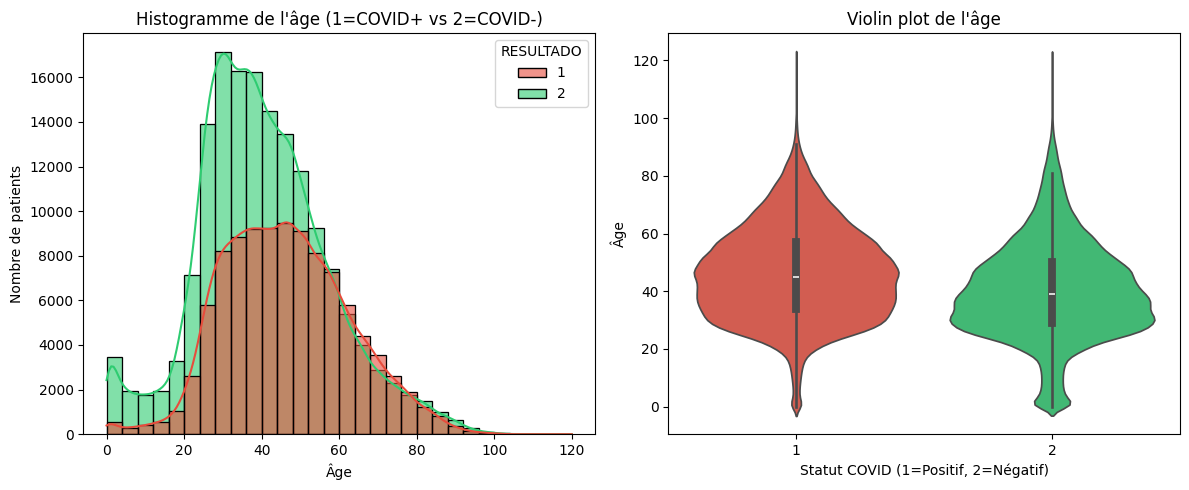

In [8]:
# ── Distribution de l'Âge (EDAD) ──────────────────────────────────────────
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df_clean, x='Age', hue=COL_GROUPE, palette=['#e74c3c', '#2ecc71'], kde=True, bins=30, alpha=0.6)
plt.title("Histogramme de l'âge (1=COVID+ vs 2=COVID-)")
plt.xlabel("Âge")
plt.ylabel("Nombre de patients")

plt.subplot(1, 2, 2)
sns.violinplot(data=df_clean, x=COL_GROUPE, y='Age', palette=['#e74c3c', '#2ecc71'])
plt.title("Violin plot de l'âge")
plt.xlabel("Statut COVID (1=Positif, 2=Négatif)")
plt.ylabel("Âge")

plt.tight_layout()
plt.show()

### 2. Fréquence des variables catégorielles (Comorbidités)

Pour les variables binaires (1 = Oui, 2 = Non), l'idéal est d'utiliser des diagrammes en barres pour observer les taux de prévalence. 
Regardons le pourcentage de patients atteints des principales comorbidités, séparés par leur statut COVID.

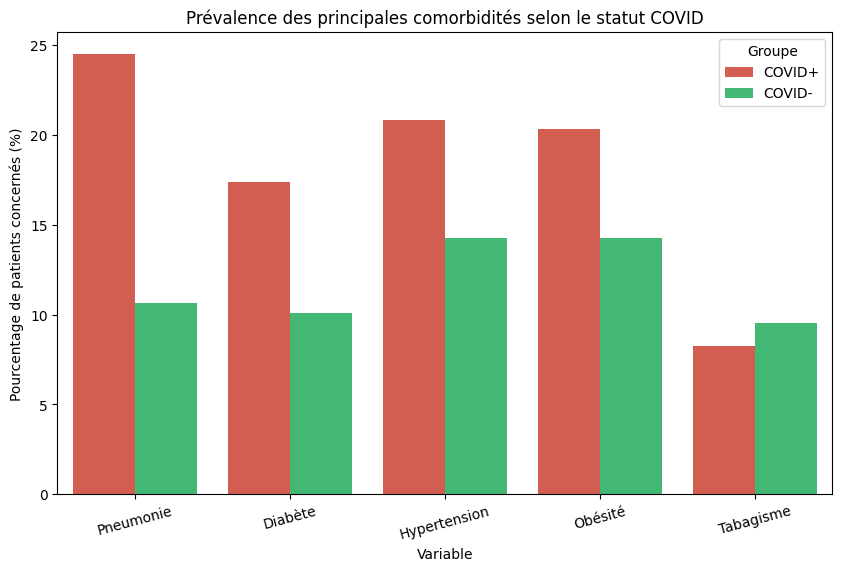

In [9]:
# ── Prévalence des Comorbidités ───────────────────────────────────────────
vars_to_plot = ['Pneumonie', 'Diabète', 'Hypertension', 'Obésité', 'Tabagisme']

plot_data = []
for var in vars_to_plot:
    for groupe_val, groupe_nom in zip([1, 2], ['COVID+', 'COVID-']):
        subset = df_clean[df_clean[COL_GROUPE] == groupe_val]
        # Taux de présence = (nombre de 1) / (total valides) * 100
        taux = (subset[var] == 1).mean() * 100
        plot_data.append({'Variable': var, 'Groupe': groupe_nom, 'Prévalence (%)': taux})

df_prev = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_prev, x='Variable', y='Prévalence (%)', hue='Groupe', palette={'COVID+': '#e74c3c', 'COVID-': '#2ecc71'})
plt.title("Prévalence des principales comorbidités selon le statut COVID")
plt.ylabel("Pourcentage de patients concernés (%)")
plt.xticks(rotation=15)
plt.show()

### 3. Matrice de corrélation (Variables binaires)

La matrice de corrélation reste un excellent outil. On recode temporairement les valeurs `1/2` en `1/0` pour que le calcul (coefficient Phi pour les variables binaires) soit interprétable : une corrélation positive signifiera que la présence d'une condition est liée à la présence d'une autre.

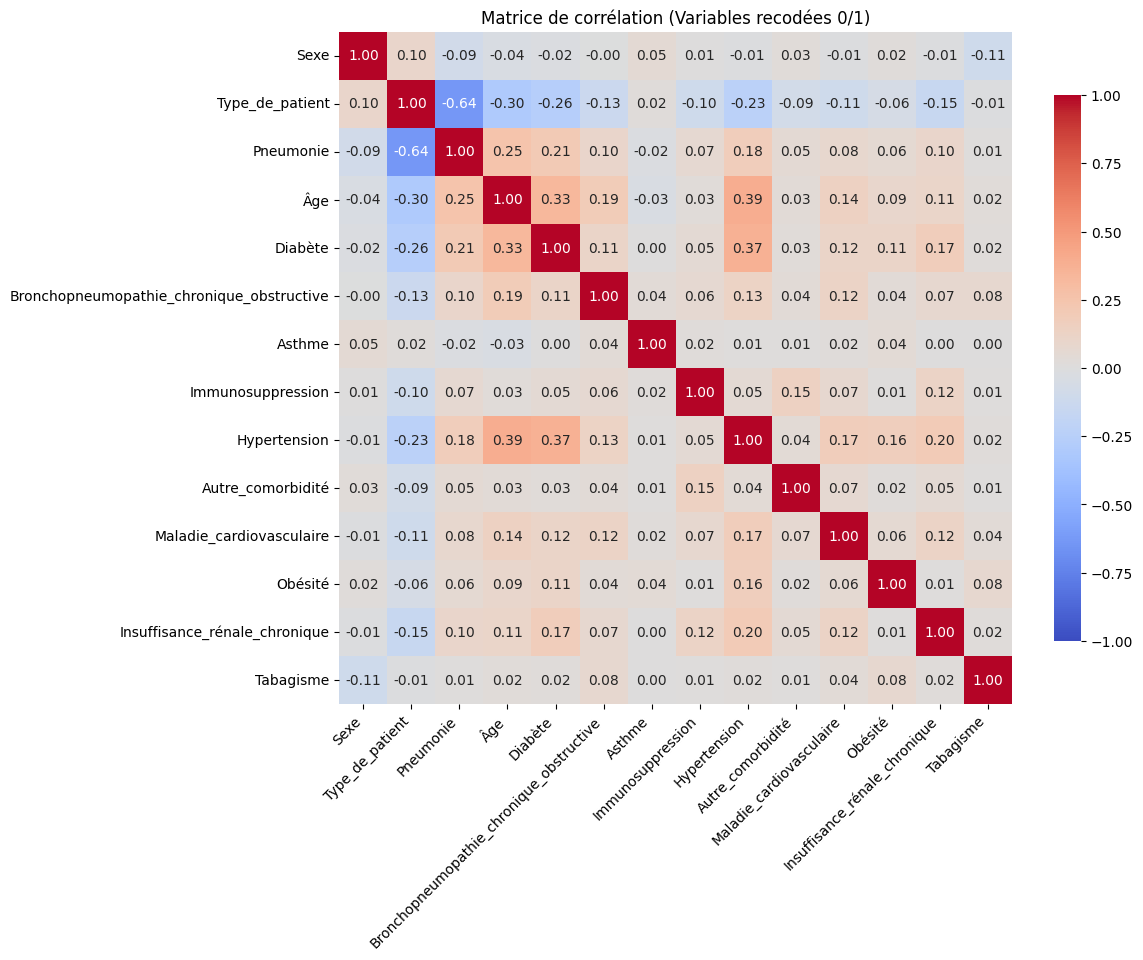

In [10]:
# ── Matrice de corrélation ────────────────────────────────────────────────
# On recode 1=Oui en 1, et 2=Non en 0 pour le calcul de corrélation
df_corr = df_clean[COLS_CLINIQUES_FR].copy()
binary_cols = [c for c in COLS_CLINIQUES_FR if c != 'Age']
df_corr[binary_cols] = (df_corr[binary_cols] == 1).astype(int)

# On renomme en français pour l'affichage
# df_corr.rename(columns=COL_NAME_FR, inplace=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_corr.corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, square=True,
    cbar_kws={'shrink': 0.75}
)
plt.title('Matrice de corrélation (Variables recodées 0/1)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 4. Graphique de profil (Pourquoi normaliser ?)

Tu te demandes peut-être s'il est nécessaire de normaliser alors qu'on a surtout du binaire. La réponse est **OUI, absolument**.

L'âge varie de 0 à plus de 100, tandis que les comorbidités varient de 1 à 2. Dans un algorithme basé sur la distance (comme le K-Means) ou la variance (comme la PCA), une différence de 30 ans d'âge écrasera complètement la différence entre "Diabète = Oui" et "Diabète = Non". L'âge dominera 100% de l'algorithme.

Ce graphique de profil (qui trace toutes les variables brutes de 200 patients) le montre visuellement : l'âge forme la grande courbe au-dessus, et les variables binaires forment deux lignes plates écrasées en bas.

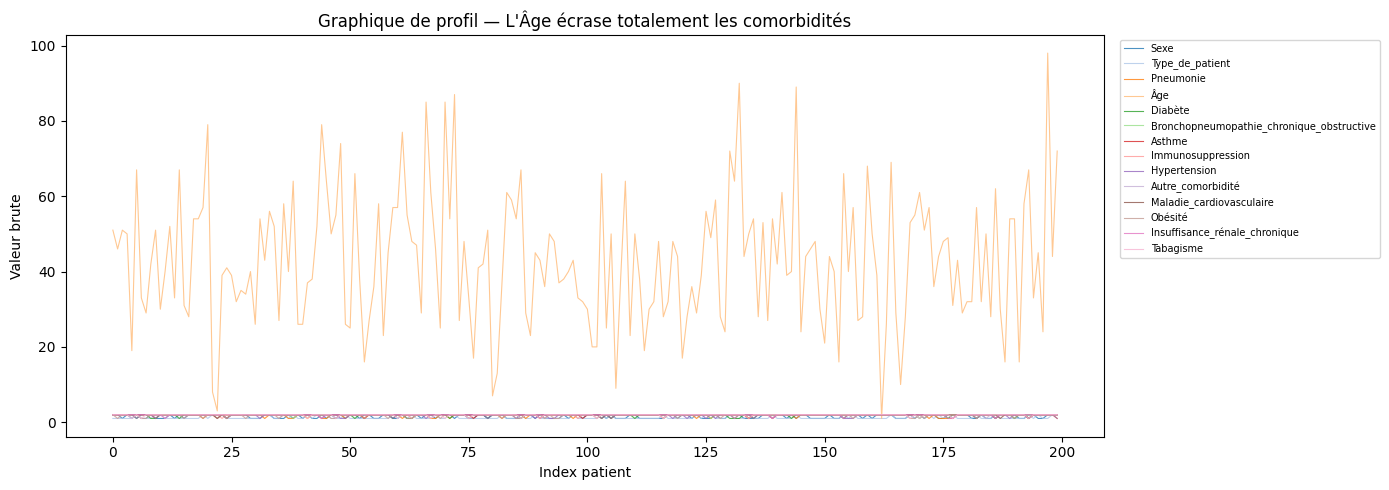

In [11]:
# ── Graphique de profil – données brutes ───────────────────────────────────
N_PROFILE = 200
df_profile = data_fr.sample(n=N_PROFILE, random_state=0).reset_index(drop=True)
palette = plt.cm.tab20.colors

plt.figure(figsize=(14, 5))
for i, col in enumerate(df_profile.columns):
    plt.plot(
        df_profile.index, df_profile[col],
        color=palette[i % len(palette)],
        linewidth=0.8, alpha=0.8, label=col
    )

plt.xlabel('Index patient')
plt.ylabel('Valeur brute')
plt.title('Graphique de profil — L\'Âge écrase totalement les comorbidités')
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
plt.tight_layout()
plt.show()

## Statistiques récapitulatives par variable clinique

On calcule la **moyenne** et l'**écart-type** de chaque variable clinique du dataset COVID mexicain. Ces statistiques permettent de quantifier la dispersion des valeurs brutes et de confirmer l'hétérogénéité des échelles.

On utilise les fonctions `mean()` et `std()` de `numpy`, appliquées au DataFrame via `apply()`. Le résultat est stocké dans un DataFrame `stats` avec une ligne par variable.

In [12]:
# ── Statistiques récapitulatives ────────────────────────────────────────────
stats = pd.DataFrame({
    'mean': data.apply(np.mean),
    'std' : data.apply(np.std)
})

print("Statistiques récapitulatives — données brutes, sans normalisation :")
print(stats.to_string())

Statistiques récapitulatives — données brutes, sans normalisation :
                     mean        std
SEXO             1.509825   0.499903
TIPO_PACIENTE    1.234322   0.423574
NEUMONIA         1.839586   0.366989
EDAD            42.546311  16.884080
DIABETES         1.870814   0.335405
EPOC             1.980320   0.138900
ASMA             1.963698   0.187042
INMUSUPR         1.980841   0.137084
HIPERTENSION     1.831676   0.374154
OTRA_COM         1.963360   0.187876
CARDIOVASCULAR   1.974279   0.158301
OBESIDAD         1.833588   0.372450
RENAL_CRONICA    1.978246   0.145879
TABAQUISMO       1.909754   0.286534


Les échelles sont confirmées comme étant disparates : `EDAD` (âge continu, moyenne ~42, std ~17) domine largement les variables binaires (moyenne ~1.5–2.0, std < 0.5). Cela confirme la nécessité d'une **normalisation** à l'étape suivante, pour qu'aucune variable ne domine numériquement l'analyse multivariée (PCA, K-means).

Le but est de pouvoir identifier et garder les colonnes cliniques les plus importantes pour le clustering.

## Export des données nettoyées (Layer Silver)

Afin de structurer le projet proprement (approche d'architecture médaillon), on sauvegarde notre DataFrame nettoyé dans la couche `Silver`.
Ce fichier ne contient plus de valeurs aberrantes (les `97/98/99` ont été gérés) et ne conserve que les colonnes cliniques pertinentes ainsi que notre label (`RESULTADO`).
Il servira de point de départ pour le prochain notebook (Normalisation et PCA).

In [ ]:


# On sauvegarde df_clean (qui contient les colonnes cliniques retenues + RESULTADO)
df_clean.to_csv(f'../../data/layer_silver_data_transform/covid_cleaned.csv', index=False)

